In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/My Drive/Colab Notebooks/Glovo/Datos_Glovo.xlsx'
df = pd.read_excel(file_path)
df.head()

,Unnamed: 0,Unnamed: 1,Fecha,Hora,Numero Factura,Base imponible,IVA,Total Factura,Propina
0,NaN,Factura partner,6/11/2024,12:59,ES-WKUK2Y6-000001/24,3.00,0.63,3.63,0.0
1,NaN,Factura partner,6/11/2024,19:55,ES-WKUK2Y6-000002/24,4.42,0.93,5.35,0.0
2,NaN,Factura cliente,6/11/2024,20:16,ES-WKUK2Y6-000003/24,3.30,0.69,3.99,0.0
3,NaN,Factura partner,6/11/2024,20:16,ES-WKUK2Y6-000004/24,1.25,0.26,1.51,0.0
4,NaN,Factura cliente,6/11/2024,20:49,ES-WKUK2Y6-000005/24,2.88,0.61,3.49,0.0


In [3]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

In [4]:
df.head()

,Unnamed: 0,Unnamed: 1,Fecha,Hora,Numero Factura,Base imponible,IVA,Total Factura,Propina
0,NaN,Factura partner,2024-11-06,12:59,ES-WKUK2Y6-000001/24,3.00,0.63,3.63,0.0
1,NaN,Factura partner,2024-11-06,19:55,ES-WKUK2Y6-000002/24,4.42,0.93,5.35,0.0
2,NaN,Factura cliente,2024-11-06,20:16,ES-WKUK2Y6-000003/24,3.30,0.69,3.99,0.0
3,NaN,Factura partner,2024-11-06,20:16,ES-WKUK2Y6-000004/24,1.25,0.26,1.51,0.0
4,NaN,Factura cliente,2024-11-06,20:49,ES-WKUK2Y6-000005/24,2.88,0.61,3.49,0.0


In [5]:
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month

In [6]:
ventas_por_mes = df.groupby(["Año","Mes"])["Total Factura"].sum()

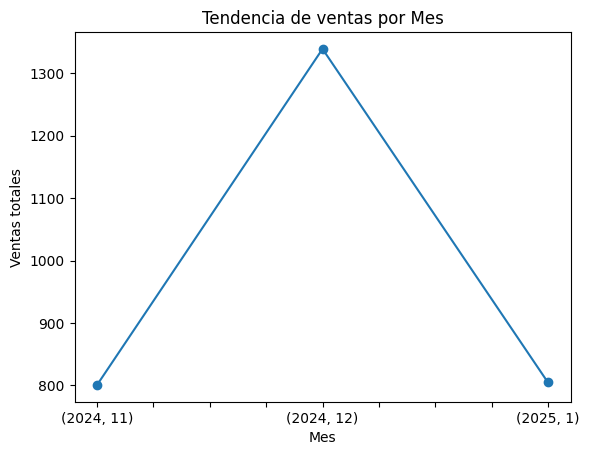

In [9]:
ventas_por_mes.plot(kind="line", marker="o")
plt.xlabel("Mes")
plt.ylabel("Ventas totales")
plt.title("Tendencia de ventas por Mes")
plt.show()

In [10]:
ventas_por_mes_año = df.groupby(["Año", "Mes"])["Total Factura"].sum().reset_index()

In [11]:
print(ventas_por_mes_año)

    Año  Mes  Total Factura
0  2024   11         800.81
1  2024   12        1339.06
2  2025    1         804.73


In [12]:
media_ventas = ventas_por_mes_año["Total Factura"].mean()
print("Media de ventas:", media_ventas)

Media de ventas: 981.5333333333333


In [15]:
ventas_por_mes.mean()

981.5333333333333

In [16]:
ventas_por_mes.median()

804.73

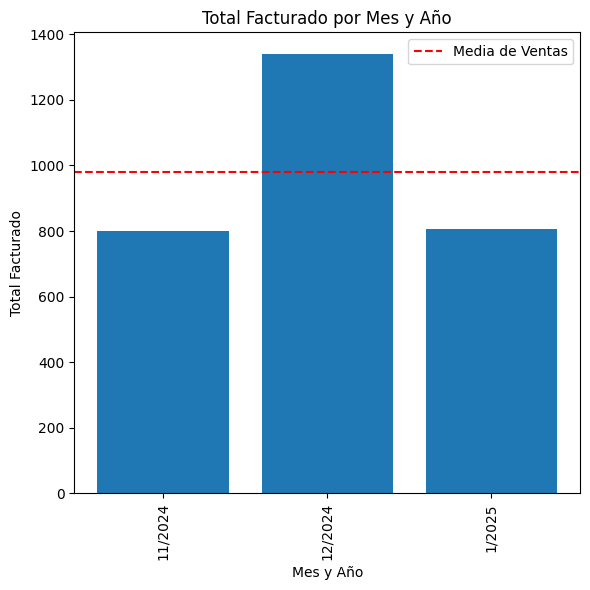

In [20]:
plt.figure(figsize=(6, 6))
plt.bar(ventas_por_mes_año.index, ventas_por_mes_año["Total Factura"])
plt.xlabel("Mes y Año")
plt.ylabel("Total Facturado")
plt.title("Total Facturado por Mes y Año")
plt.xticks(ventas_por_mes_año.index, ventas_por_mes_año["Mes"].astype(str) + "/" + ventas_por_mes_año["Año"].astype(str), rotation=90)

# Calcular la media de las ventas
media_ventas = ventas_por_mes_año["Total Factura"].mean()

# Agregar una línea horizontal para la media
plt.axhline(y=media_ventas, color='r', linestyle='--', label='Media de Ventas')

plt.legend() # Mostrar leyenda para identificar las líneas
plt.tight_layout()
plt.show()

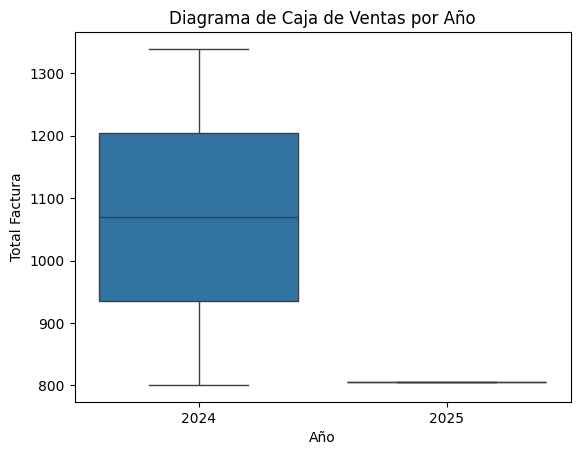

In [21]:
sns.boxplot(x="Año", y="Total Factura", data=ventas_por_mes_año)
plt.title("Diagrama de Caja de Ventas por Año")
plt.show()

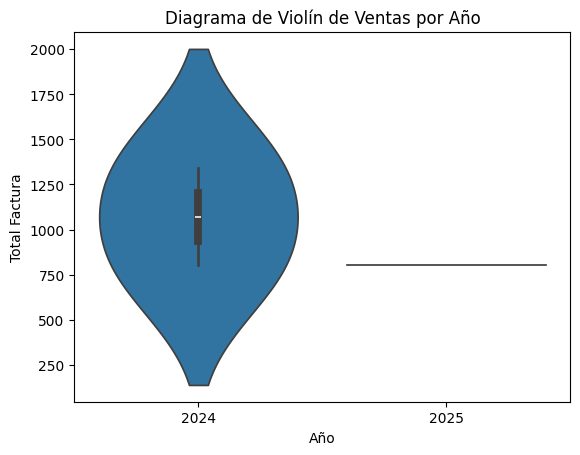

In [22]:
sns.violinplot(x="Año", y="Total Factura", data=ventas_por_mes_año)
plt.title("Diagrama de Violín de Ventas por Año")
plt.show()

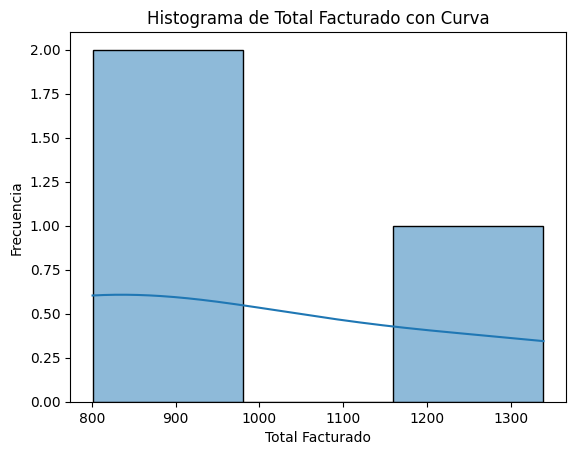

In [23]:
sns.histplot(ventas_por_mes_año["Total Factura"], kde=True)  # kde=True adds the curve

plt.xlabel("Total Facturado")
plt.ylabel("Frecuencia")
plt.title("Histograma de Total Facturado con Curva")

plt.show()